# Projet IA & Optimisation : Classification de cellules
**Membres de l'equipe :** Felix Blanchier (Groupe A1-G1A)
**Date :** Mai 2026
**Institution :** ISEP Paris

---

## Introduction & Objectif
Classifier automatiquement des patchs histologiques en 4
classes (Lymphocyte, Tumor, Plasma, Fibroblast).

*Contrainte : lignes de code < 80 caracteres.*

## I. Exploration des donnees
Objectifs : compter les echantillons, verifier la
distribution des labels, et observer l'apparence
typique des patches par classe.

In [25]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path('DATASET_images')
IMAGE_DIR = DATA_DIR / 'Training dataset - images-20260519'
FEATURES_CSV = Path('features_train.csv')
RANDOM_STATE = 42

In [26]:
train_df = pd.read_csv('train.csv')

print('Nombre total :', len(train_df))
labels = sorted(train_df['Label'].unique())
print('Labels :', labels)
print(train_df['Label'].value_counts())

Nombre total : 400
Labels : ['Fibroblast', 'Lymphocyte', 'Plasma', 'Tumor']
Label
Lymphocyte    100
Tumor         100
Plasma        100
Fibroblast    100
Name: count, dtype: int64


/tmp/ipykernel_19273/3593738923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Label', palette='viridis')


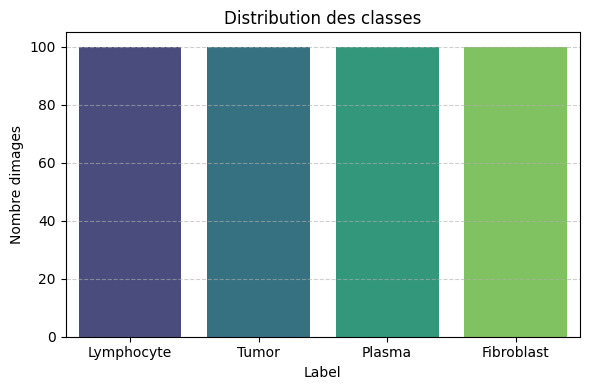

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='Label', palette='viridis')
plt.title('Distribution des classes')
plt.xlabel('Label')
plt.ylabel('Nombre dimages')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

[ WARN:0@281.049] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/5.png'): can't open/read file: check file path/integrity
[ WARN:0@281.053] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/0.png'): can't open/read file: check file path/integrity
[ WARN:0@281.053] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/3.png'): can't open/read file: check file path/integrity
[ WARN:0@281.053] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/6.png'): can't open/read file: check file path/integrity
[ WARN:0@281.054] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/8.png'): can't open/read file: check file path/integrity
[ WARN:0@281.054] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/4.png'): can't open/read file: check 

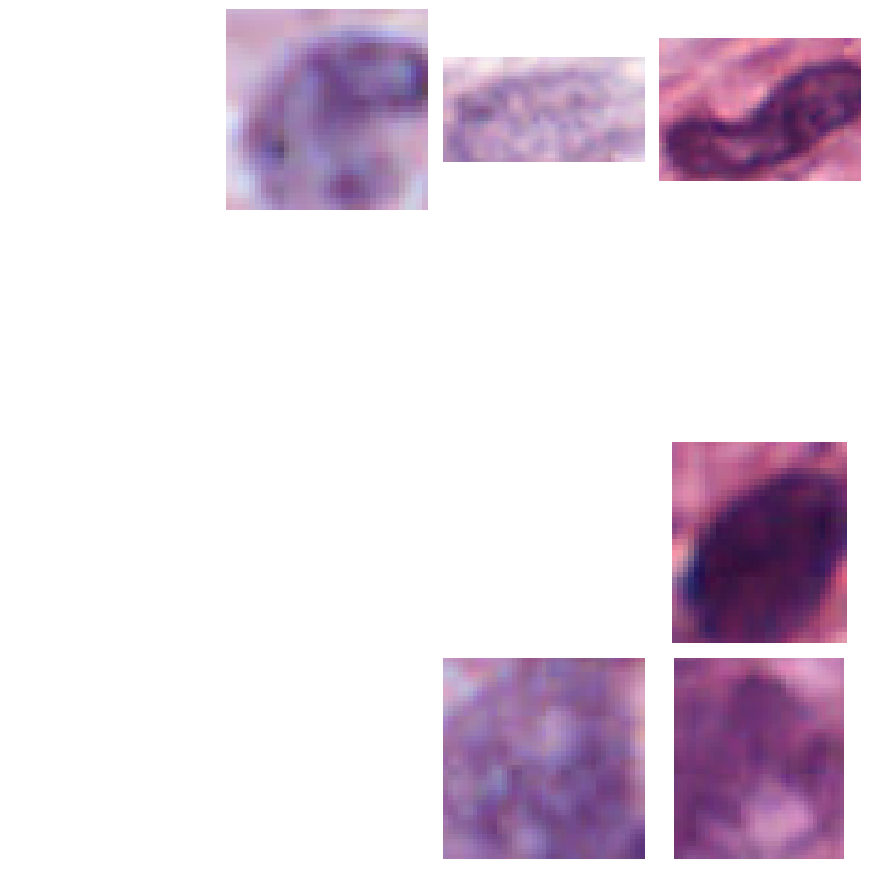

In [28]:
def show_samples(df, src_dir, labels, n=4):
    fig, axes = plt.subplots(
        len(labels), n, figsize=(n * 2.2, len(labels) * 2.2)
    )
    if len(labels) == 1:
        axes = np.array([axes])
    for i, label in enumerate(labels):
        ids = df[df['Label'] == label]['Image'].head(n)
        for j, image_id in enumerate(ids):
            path = src_dir / f'{image_id}.png'
            img = cv2.imread(str(path))
            if img is None:
                axes[i, j].axis('off')
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(label, fontsize=9)
    plt.tight_layout()
    plt.show()

show_samples(train_df, IMAGE_DIR, labels, n=4)

### Apparence commune (a completer apres observation)
- Lymphocyte : noyaux denses, ronds, textures fines.
- Tumor : formes plus grosses et contours irreguliers.
- Plasma : cytoplasme plus clair, noyaux excentres.
- Fibroblast : structures allongees, texture fibreuse.

## II. Extraction de caracteristiques
Les features couvrent **aire**, **forme** et **intensite**.
On ajoute un indicateur de texture (gradient).

In [29]:
def compute_mask(gray):
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    _, mask = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    if np.mean(mask) > 127:
        mask = cv2.bitwise_not(mask)
    return mask

def contour_features(mask):
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return 0.0, 0.0, 0.0
    cnt = max(contours, key=cv2.contourArea)
    area = float(cv2.contourArea(cnt))
    peri = float(cv2.arcLength(cnt, True))
    circ = (4.0 * np.pi * area) / (peri * peri + 1e-6)
    return area, peri, circ

def eccentricity(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) < 5:
        return 0.0
    x = xs - xs.mean()
    y = ys - ys.mean()
    cov = np.cov(np.vstack([x, y]))
    eigvals = np.linalg.eigvalsh(cov)
    if eigvals[1] <= 1e-6:
        return 0.0
    return float(np.sqrt(1 - eigvals[0] / eigvals[1]))

def extract_features(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    mask = compute_mask(gray)
    area, peri, circ = contour_features(mask)
    ecc = eccentricity(mask)

    mean_gray = float(np.mean(gray))
    std_gray = float(np.std(gray))
    mean_hsv = cv2.mean(hsv)[:3]
    std_hsv = cv2.meanStdDev(hsv)[1].flatten()[:3]

    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad = np.sqrt(sobelx ** 2 + sobely ** 2)
    grad_mean = float(np.mean(grad))
    grad_std = float(np.std(grad))

    return [
        area, peri, circ, ecc,
        mean_gray, std_gray,
        mean_hsv[0], mean_hsv[1], mean_hsv[2],
        std_hsv[0], std_hsv[1], std_hsv[2],
        grad_mean, grad_std,
    ]

In [30]:
feature_names = [
    'area', 'perimeter', 'circularity', 'eccentricity',
    'mean_gray', 'std_gray',
    'mean_h', 'mean_s', 'mean_v',
    'std_h', 'std_s', 'std_v',
    'grad_mean', 'grad_std',
]

rows = []
missing = 0
for _, row in train_df.iterrows():
    image_id = str(row['Image']).strip()
    label = str(row['Label']).strip()
    path = IMAGE_DIR / f'{image_id}.png'
    feats = extract_features(path)
    if feats is None:
        missing += 1
        continue
    rows.append([image_id, label, *feats])

columns = ['Image', 'Label'] + feature_names
features_df = pd.DataFrame(rows, columns=columns)
features_df.to_csv(FEATURES_CSV, index=False)

print('Features:', features_df.shape)
print('Images manquantes:', missing)
print(features_df.head())

[ WARN:0@281.149] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/0.png'): can't open/read file: check file path/integrity
[ WARN:0@281.149] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/1.png'): can't open/read file: check file path/integrity
[ WARN:0@281.149] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/2.png'): can't open/read file: check file path/integrity
[ WARN:0@281.149] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/3.png'): can't open/read file: check file path/integrity
[ WARN:0@281.149] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/4.png'): can't open/read file: check file path/integrity
[ WARN:0@281.149] global loadsave.cpp:278 findDecoder imread_('DATASET_images/Training dataset - images-20260519/5.png'): can't open/read file: check 

Features: (390, 16)
Images manquantes: 10
  Image       Label   area   perimeter  circularity  eccentricity   mean_gray  \
0    10  Fibroblast  326.0  139.112698     0.211687      0.453071  149.168980   
1    11  Lymphocyte  300.0  117.941125     0.271020      0.656460   60.720779   
2    12  Lymphocyte  200.5  124.870057     0.161587      0.844318   94.733333   
3    13       Tumor  474.5  143.497473     0.289573      0.589299  122.874479   
4    14  Fibroblast  380.5  161.698484     0.182874      0.909628  175.478836   

    std_gray      mean_h      mean_s      mean_v      std_h      std_s  \
0  34.241186  141.208980   66.441633  180.278367   9.536974  25.410043   
1  31.539708  151.716450  157.268398   97.660173  11.161240  25.593040   
2  66.298824  132.369231  115.429487  131.191026  17.829594  55.238354   
3  22.071844  143.375967   89.359310  159.575848   7.258726  19.225964   
4  25.364242  148.212302   47.847884  198.685847  13.004040  16.316541   

       std_v   grad_mean  

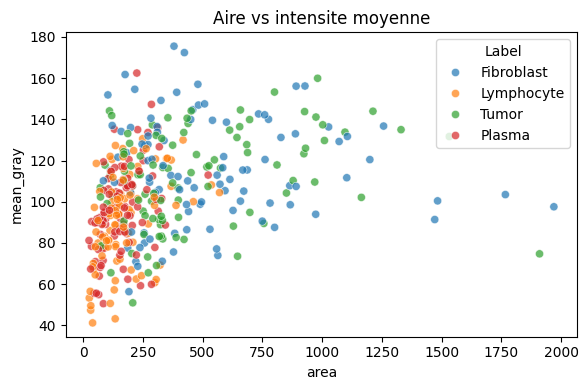

In [31]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=features_df,
    x='area',
    y='mean_gray',
    hue='Label',
    alpha=0.7,
    s=35
)
plt.title('Aire vs intensite moyenne')
plt.tight_layout()
plt.show()

## III. Modelisation et optimisation
Deux algorithmes : SVM et Random Forest.
On applique selection de features, normalisation
et validation croisee (GridSearchCV).

Hyperparametres ajustes :
- SVM : C (marge/erreur), gamma (complexite).
- RF : n_estimators (stabilite), max_depth et
  min_samples (regularisation).

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, accuracy_score

X = features_df[feature_names].values
y = features_df['Label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=8)),
    ('model', SVC())
])

rf_pipe = Pipeline([
    ('select', SelectKBest(f_classif, k=8)),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE
    )),
])

svm_params = {
    'select__k': [6, 8, 10],
    'model__C': [0.5, 1, 2, 4],
    'model__gamma': ['scale', 0.1],
    'model__kernel': ['rbf']
}

rf_params = {
    'select__k': [6, 8, 10],
    'model__n_estimators': [200, 500],
    'model__max_depth': [None, 12, 20],
    'model__min_samples_split': [2, 4],
    'model__min_samples_leaf': [1, 2]
}

grid_svm = GridSearchCV(
    svm_pipe, svm_params, cv=cv, scoring='f1_macro', n_jobs=-1
)
grid_rf = GridSearchCV(
    rf_pipe, rf_params, cv=cv, scoring='f1_macro', n_jobs=-1
)

grid_svm.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print('SVM best:', grid_svm.best_params_)
print('SVM CV f1:', grid_svm.best_score_)
print('RF best:', grid_rf.best_params_)
print('RF CV f1:', grid_rf.best_score_)

best_model = grid_svm
if grid_rf.best_score_ > grid_svm.best_score_:
    best_model = grid_rf

print('Modele retenu:', type(best_model.best_estimator_))

/home/felix/miniforge3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


SVM best: {'model__C': 2, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'select__k': 10}
SVM CV f1: 0.6551941270507406
RF best: {'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 500, 'select__k': 10}
RF CV f1: 0.6505767728827501
Modele retenu: <class 'sklearn.pipeline.Pipeline'>


In [33]:
y_pred = best_model.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1 macro:', f1_score(y_val, y_pred, average='macro'))
print(classification_report(y_val, y_pred))

Accuracy: 0.6410256410256411
F1 macro: 0.6383165459772847
              precision    recall  f1-score   support

  Fibroblast       0.77      0.85      0.81        20
  Lymphocyte       0.60      0.47      0.53        19
      Plasma       0.46      0.58      0.51        19
       Tumor       0.76      0.65      0.70        20

    accuracy                           0.64        78
   macro avg       0.65      0.64      0.64        78
weighted avg       0.65      0.64      0.64        78



## IV. Test sur le dataset de base
On reutilise le dataset d'origine (non trie) pour
mesurer la proportion de predictions correctes.
Ce n'est pas un vrai test, juste un controle.

Si un dossier de test est fourni plus tard, le
fichier test.csv est genere automatiquement.

In [34]:
X_all = features_df[feature_names].values
y_true = features_df['Label'].values
y_pred_all = best_model.predict(X_all)

acc_all = np.mean(y_pred_all == y_true)
print('Proportion correcte (dataset base) :', acc_all)

TEST_DIR_EXTERNAL = DATA_DIR / 'test dataset - images'

def predict_test_folder(test_dir, model):
    image_paths = sorted(test_dir.glob('*.png'))
    rows = []
    for path in image_paths:
        feats = extract_features(path)
        if feats is None:
            continue
        pred = model.predict([feats])[0]
        rows.append({'Image': path.stem, 'Label': pred})
    return pd.DataFrame(rows)

if TEST_DIR_EXTERNAL.exists():
    test_df = predict_test_folder(
        TEST_DIR_EXTERNAL, best_model.best_estimator_
    )
    test_df.to_csv('test.csv', index=False)
    print('test.csv genere:', len(test_df))
else:
    print('Dossier test manquant:', TEST_DIR_EXTERNAL)

Proportion correcte (dataset base) : 0.7307692307692307
Dossier test manquant: DATASET_images/test dataset - images
